In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from matplotlib import colors
from matplotlib.colors import LogNorm
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy import stats
import illustris_python as il
from astropy import units as u
# from match_with_crash import get_crash_df_with_semi
from plotting_routines import *
from utils import *
import h5py
from utils import *
from astropy import constants as c
from utils import load_df

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from build_full_df import merge_dfs
from plotting_routines import *

In [4]:
from utils import get_sim
import h5py

In [5]:
from merger_history import update_merger_time
from merger_history import most_recent_merger
from merger_history import *
from config import config

In [6]:
from fitting_fesc import get_fesc_fit

In [7]:
num = 16
path = f'/ptmp/mpa/ivkos/semianalytic_fesc/sn0{num}/test_{num}.pickle'
df = pd.read_pickle(path)

In [9]:
merge_dfs(0,16, name='extended_df', name_prefix_dfs='test')

In [9]:
path = '/ptmp/mpa/ivkos/semianalytic_fesc/extended_df.pickle'
df_full = load_df(path)

In [9]:
from gridded_maps import select_sphere_gas, get_relative_coord
from utils import scale_factor

In [25]:
path = '/ptmp/mpa/ivkos/semianalytic_fesc/sn016/test_16.pickle'
df = pd.read_pickle(path)

In [15]:
filter_loc = (np.log10(df_full['Column_height'])>21.0)
filter_ext = (np.log10(df_full['Column_height'])<21.0)
df_full = df_full[df_full.z<11]
df_extended = df_full[(np.log10(df_full['Column_height'])<21.0)]
df_localized = df_full[(np.log10(df_full['Column_height'])>21.0)]

In [45]:
filt1 = (df_full['TimeMajorMerger']<60)
filt2 = (df_full.M_star_sun_log>6.8)&(df_full.M_star_sun_log>7.2) 
filt = filt1&filt2
df_full[filt]['Dist_nearest'].median()

47.172200246034585

In [44]:
filt1 = (df_full['TimeMajorMerger']>400)
filt2 = (df_full.M_star_sun_log>6.8)&(df_full.M_star_sun_log>7.2) 
filt = filt1&filt2
df_full[filt]['Dist_nearest'].median()

66.24537658691406

In [35]:
fixed_z = df_full.z.unique()[16]histograms

In [64]:
df_full['v_sigma'] = df_full['v_max']/df_full['abs_sigma_sfr']

In [33]:
from offset_ang_mom import get_pos_cm, get_pec_vel, mass_to_g

In [13]:
df_full.keys()

Index(['r', 'Halo_pos_x', 'Halo_pos_y', 'Halo_pos_z', 'Grid_cell_size',
       'Column_height', 'Bol_em', 'Column_dens', 'Column_dens_stroemgren',
       'Dust_norm', 'Ion_em', 'M_gas', 'M_star', 'Metallicity', 'N_d',
       'N_ratio', 'N_red', 'SFR', 'U', 'U1', 'f_esc', 'f_g', 'f_g_crit',
       'n_gas', 'p_r', 'sigma_d_H', 'AverageColumnDens',
       'AverageColumnDensDust', 'AverageIonizableColumnDens', 'flow',
       'ang_momentum', 'sfr_mass_to_center_mass', 'sfr_sfr_to_center_mass',
       'abs_sigma_sfr', 'abs_sigma_mass', 'v_max', 'Dist_nearest', 'Dist_5',
       'Dist_10', 'Dist_32', 'TimeMajorMerger', 'TimeMinorMerger', 'Gini_sfr',
       'Gini_fesc', 'z', 'idx', 'M_gas_sun_log', 'M_star_sun_log', 'sSFR',
       'sZ', 'MgasMstar', 'L_M', 'Offset_pc'],
      dtype='object')

/freya/u/ivkos/semianalytic/plotting_routines.py:2082: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/freya/u/ivkos/semianalytic/plotting_routines.py:2082: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/freya/u/ivkos/semianalytic/plotting_routines.py:2082: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.h

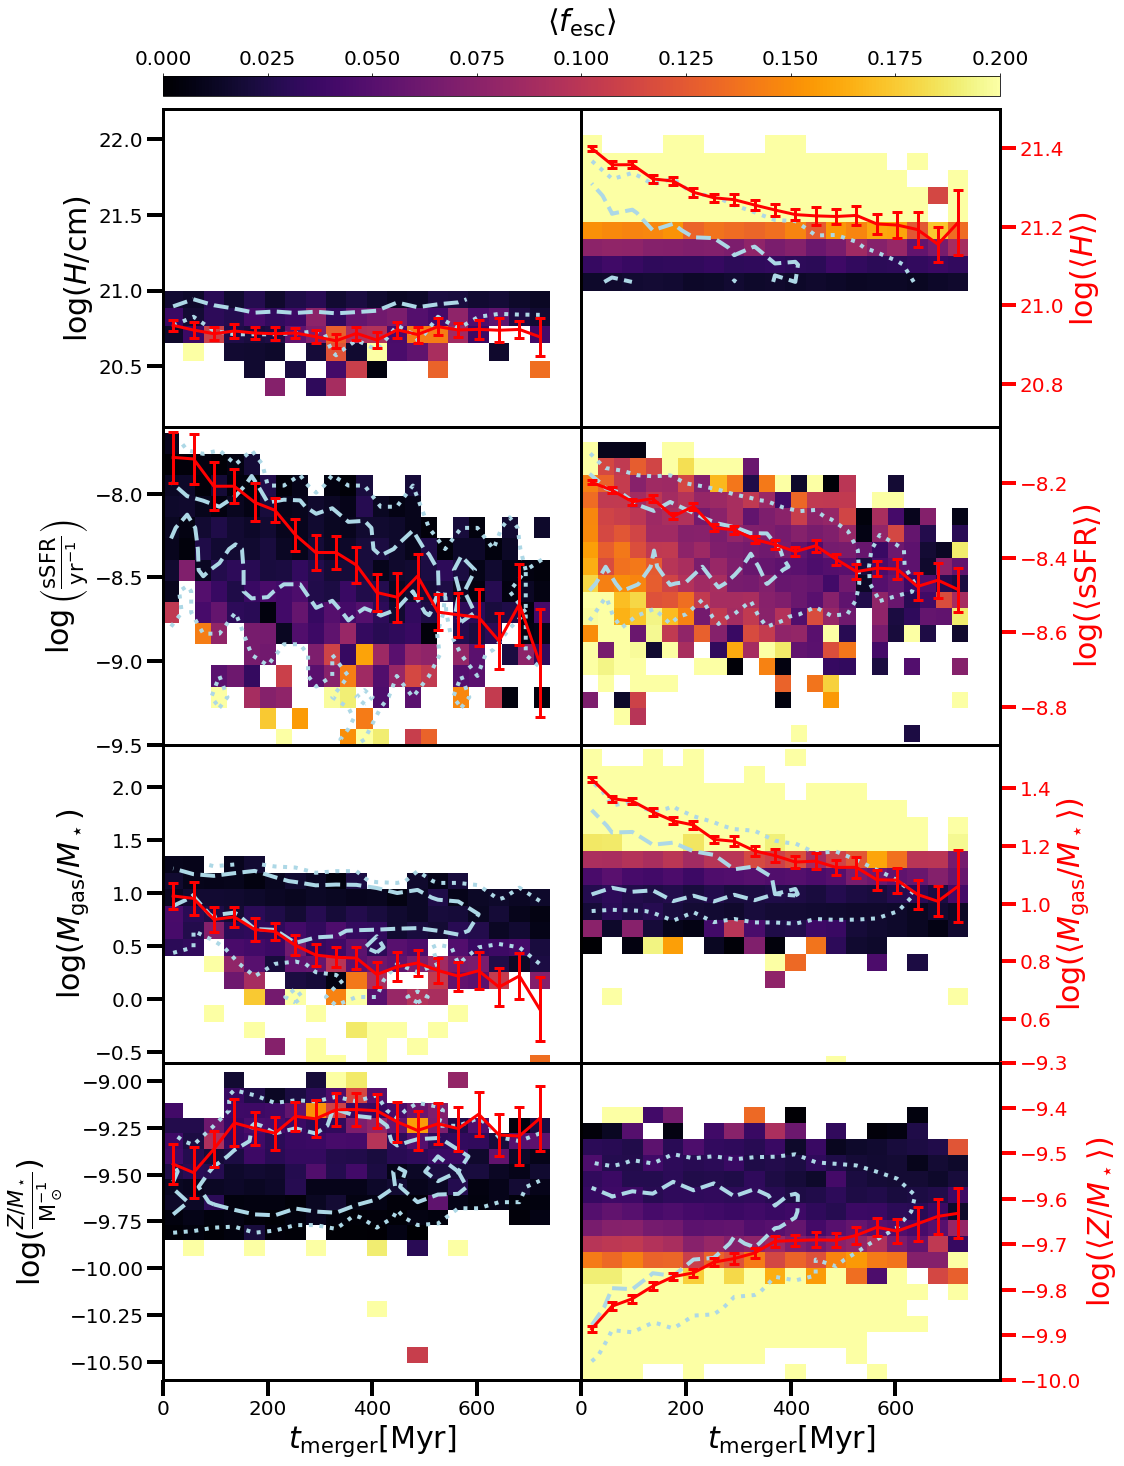

In [78]:
histograms_plot(
    df_full,
    color_prop="f_esc",
    statistic="mean",
    bins_x=30,
    bins_y=30,
    params=None,
    contour=True,
    add_line=True,
)

In [ ]:
df_full

/freya/u/ivkos/semianalytic/plotting_routines.py:1694: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset="f_esc", inplace=True)


211488


/u/ivkos/conda-envs/semianalytic/lib/python3.10/site-packages/numpy/core/_methods.py:44: RuntimeWarning: invalid value encountered in reduce
  return umr_minimum(a, axis, None, out, keepdims, initial, where)
/u/ivkos/conda-envs/semianalytic/lib/python3.10/site-packages/numpy/core/_methods.py:40: RuntimeWarning: invalid value encountered in reduce
  return umr_maximum(a, axis, None, out, keepdims, initial, where)
/u/ivkos/conda-envs/semianalytic/lib/python3.10/site-packages/numpy/core/_methods.py:44: RuntimeWarning: invalid value encountered in reduce
  return umr_minimum(a, axis, None, out, keepdims, initial, where)
/u/ivkos/conda-envs/semianalytic/lib/python3.10/site-packages/numpy/core/_methods.py:40: RuntimeWarning: invalid value encountered in reduce
  return umr_maximum(a, axis, None, out, keepdims, initial, where)
/u/ivkos/conda-envs/semianalytic/lib/python3.10/site-packages/numpy/core/_methods.py:44: RuntimeWarning: invalid value encountered in reduce
  return umr_minimum(a, axi

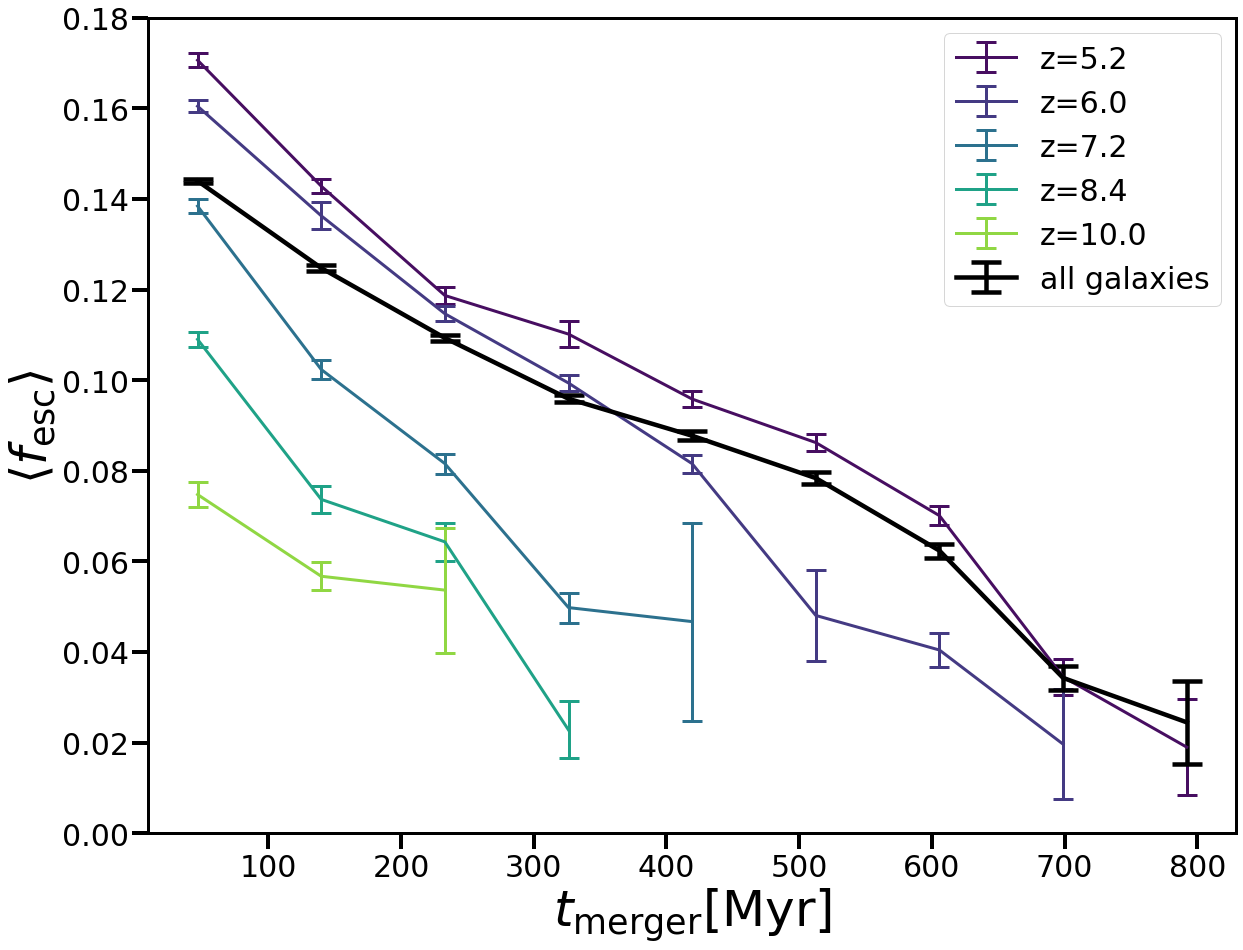

In [38]:
# filter = (df_full.M_star_sun_log>6.8)&(df_full.M_star_sun_log<7.2)
lineplots(
    df_full[df_full.z<11],
    mass_bins=10,
    em_weighted=False,
    x_prop="TimeMajorMerger",
    y_prop="f_esc",
    skip=3,
    params=None,
    log=False,
    individual_z=True,
    x_log=False,
    all=True,
    with_mass_bins=False,
    two_modes=False,
    filters=None,
)

/freya/u/ivkos/semianalytic/plotting_routines.py:1694: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset="f_esc", inplace=True)
/freya/u/ivkos/semianalytic/plotting_routines.py:1743: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df1 = df[filters[0]]
/freya/u/ivkos/semianalytic/plotting_routines.py:1744: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df2 = df[filters[1]]
/u/ivkos/conda-envs/semianalytic/lib/python3.10/site-packages/numpy/core/_methods.py:44: RuntimeWarning: invalid value encountered in reduce
  return umr_minimum(a, axis, None, out, keepdims, initial, where)
/u/ivkos/conda-envs/semianalytic/lib/python3.10/site-packages/numpy/core/_methods.py:40: RuntimeWarning: invalid value encountered in reduce
  return umr_ma

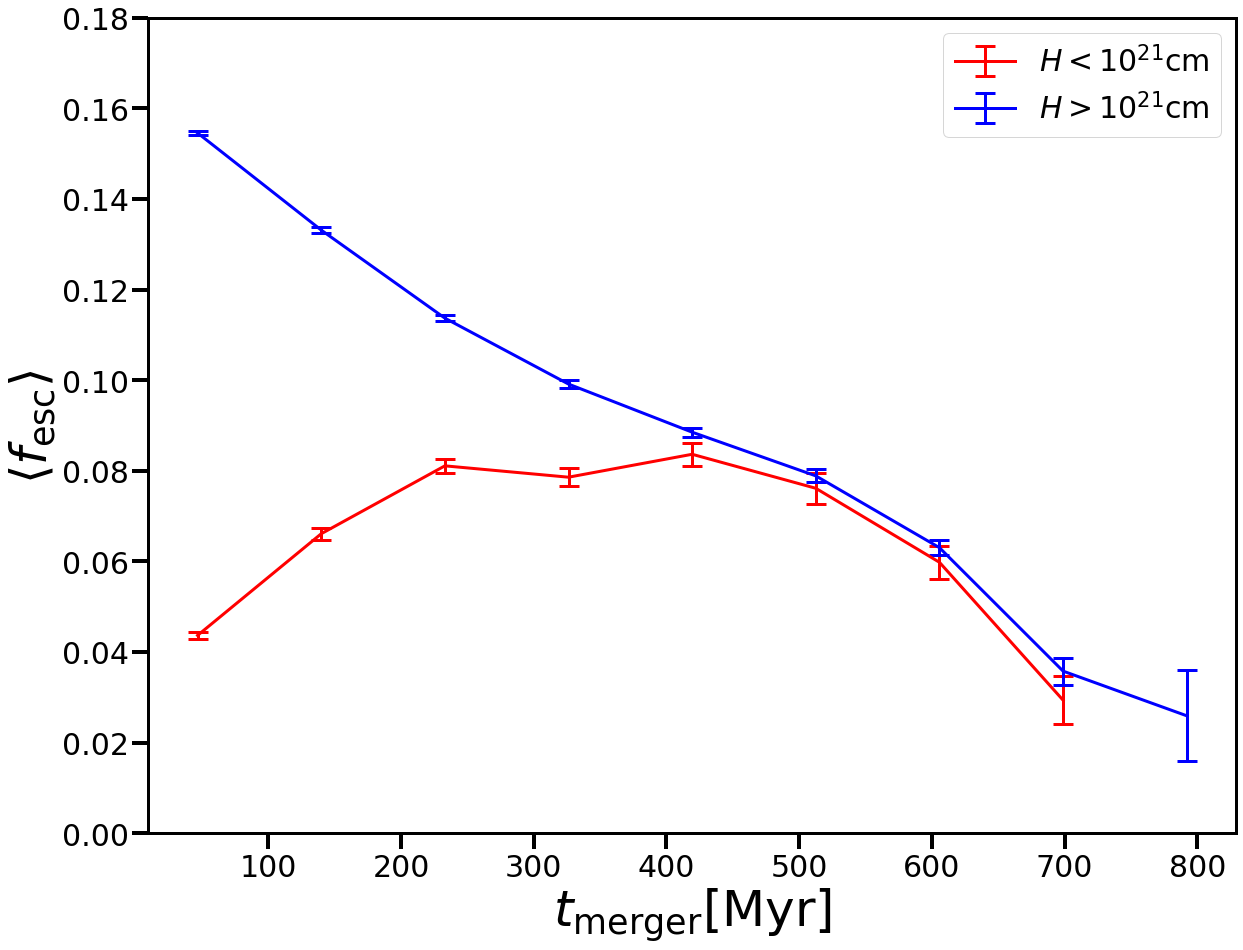

In [32]:
filter_loc = (np.log10(df_full['Column_height'])>21.0)
filter_ext = (np.log10(df_full['Column_height'])<21.0)
lineplots(
    df_full[df_full.z<11],
    mass_bins=10,
    em_weighted=False,
    x_prop="TimeMajorMerger",
    y_prop="f_esc",
    skip=0,
    params=None,
    log=False,
    individual_z=False,
    x_log=False,
    all=False,
    with_mass_bins=False,
    two_modes=True,
    filters=[filter_ext, filter_loc],
)

/freya/u/ivkos/semianalytic/plotting_routines.py:1274: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if x_prop == "TimeMajorMerger":
/freya/u/ivkos/semianalytic/plotting_routines.py:1281: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/u/ivkos/conda-envs/semianalytic/lib/python3.10/site-packages/numpy/core/_methods.py:44: RuntimeWarning: invalid value encountered in reduce
  return umr_minimum(a, axis, None, out, keepdims, initial, where)
/u/ivkos/conda-envs/semianalytic/lib/python3.10/site-packages/numpy/core/_methods.py:40: RuntimeWarning: invalid value encount

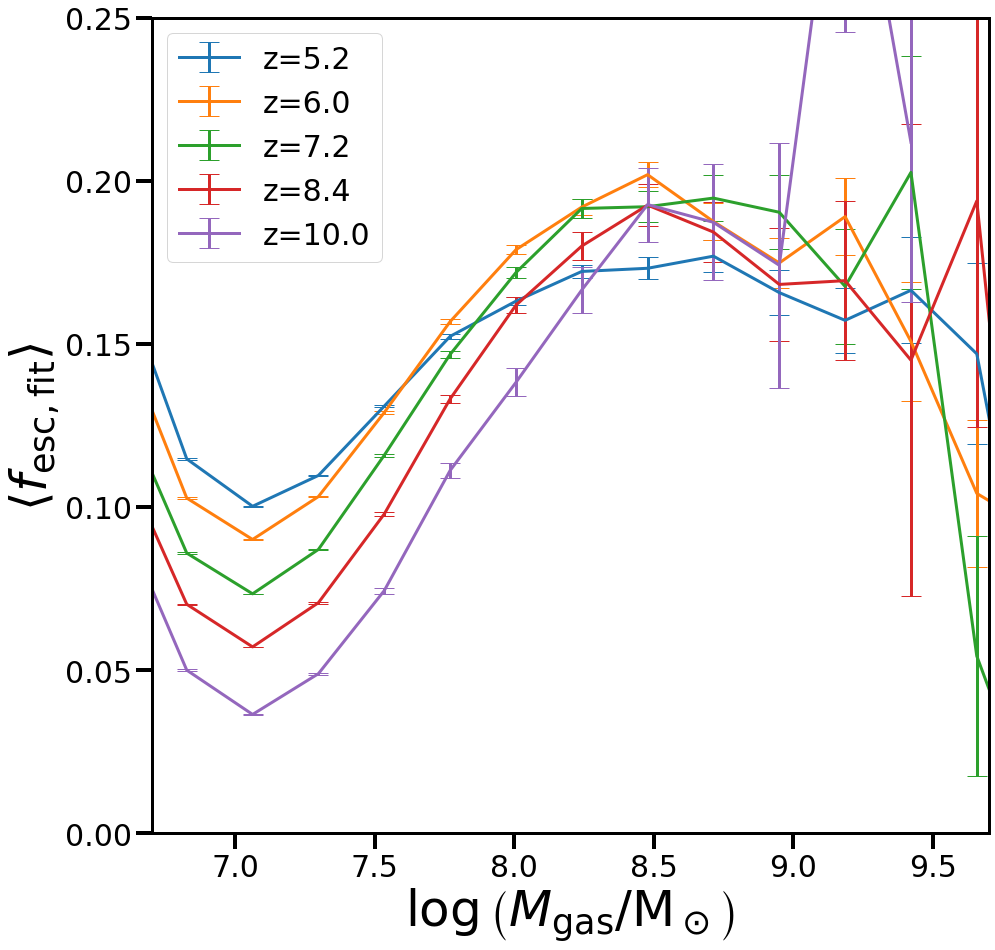

In [83]:
fesc_Mstar(df_full[df_full.z<11], x_prop='M_gas_sun_log',  mass_bins=20,skip=3)

In [81]:
maps_name = os.path.join(config['base_path'], 'sn003', 'new_maps_3.hdf5')
hdf = h5py.File(maps_name, "r")

In [113]:
hdf['100']['1'].keys()

<KeysViewHDF5 ['Bol_flux', 'Column_dens', 'Column_dens_stroemgren', 'Dust_norm', 'Ion_flux', 'M_gas', 'M_star', 'Metallicity', 'N_d', 'N_ratio', 'N_red', 'SFR', 'Sigma_SFR', 'Sigma_gas', 'Sigma_star', 'U', 'U1', 'f_esc', 'f_g', 'f_g_crit', 'n_gas', 'p_g', 'p_r', 'sigma_d_H', 'tau_d', 'v_inf', 'w']>

In [ ]:
df_full['Column_dens']

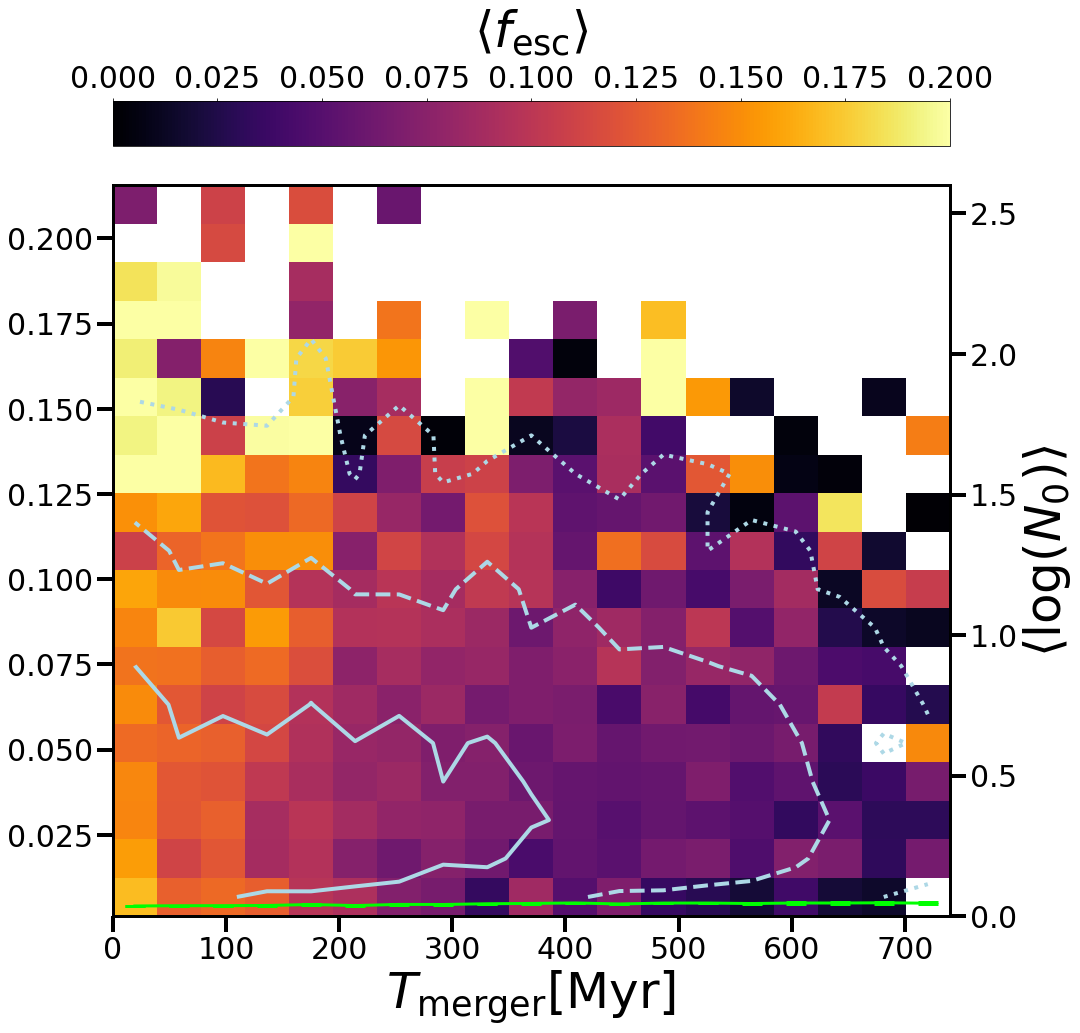

In [28]:
filter = (df_full.f_esc>0)&(np.log10(df_full.Column_height)>21)&(df_full.M_star_sun_log>6.8)&(df_full.M_star_sun_log<7.2)
prop_prop_histogram(df_full[filter], 'TimeMajorMerger', 'RelativeColumnDensDust', 
                    log_x=False, log_y=False, add_line=True, line_log=False, bins_x=20, bins_y=20)

/freya/u/ivkos/semianalytic/plotting_routines.py:2105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["prop_bins"] = pd.cut(
/freya/u/ivkos/semianalytic/plotting_routines.py:2105: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["prop_bins"] = pd.cut(


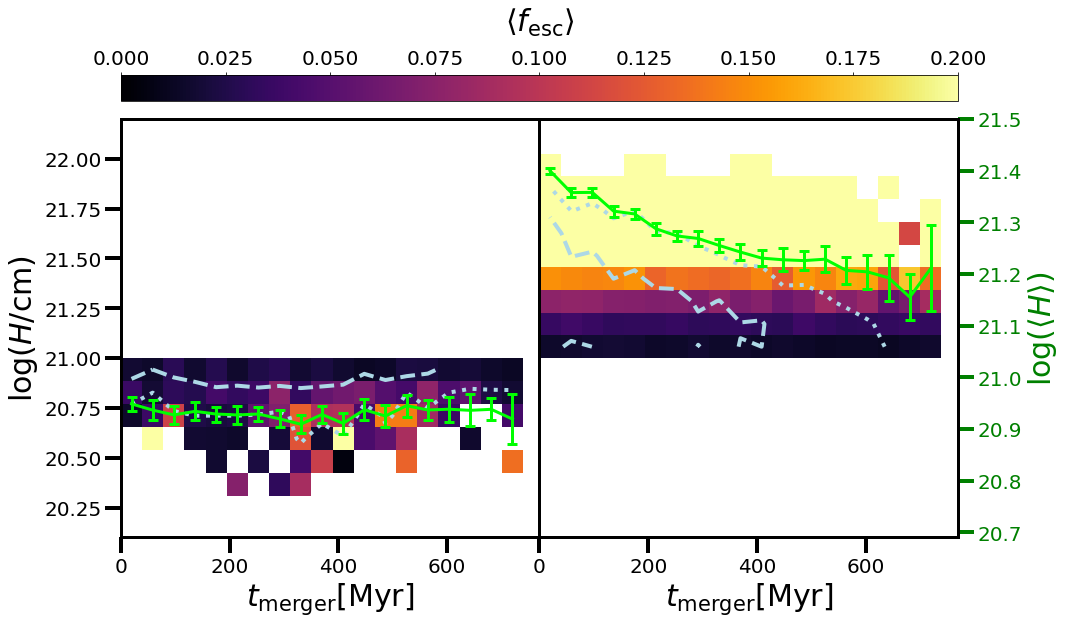

In [12]:
modes_plot(df_full, add_line=True)

In [16]:
mass_filter = (df_full.M_star_sun_log > 6.8) & (
        df_full.M_star_sun_log < 7.2
    )
np.log10(df_full[mass_filter]['Offset_pc']).describe()

/u/ivkos/conda-envs/semianalytic/lib/python3.10/site-packages/pandas/core/arraylike.py:397: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


count    3.376400e+04
mean             -inf
std               NaN
min              -inf
25%      1.684541e+00
50%      2.017228e+00
75%      2.341536e+00
max      3.718114e+00
Name: Offset_pc, dtype: float64

In [16]:
df_full.keys()

Index(['r', 'Halo_pos_x', 'Halo_pos_y', 'Halo_pos_z', 'Grid_cell_size',
       'Column_height', 'Bol_em', 'Column_dens', 'Column_dens_stroemgren',
       'Dust_norm', 'Ion_em', 'M_gas', 'M_star', 'Metallicity', 'N_d',
       'N_ratio', 'N_red', 'SFR', 'U', 'U1', 'f_esc', 'f_g', 'f_g_crit',
       'n_gas', 'p_r', 'sigma_d_H', 'AverageColumnDens',
       'AverageColumnDensDust', 'AverageIonizableColumnDens', 'flow',
       'ang_momentum', 'sfr_mass_to_center_mass', 'sfr_sfr_to_center_mass',
       'abs_sigma_sfr', 'abs_sigma_mass', 'v_max', 'Dist_nearest', 'Dist_5',
       'Dist_10', 'Dist_32', 'TimeMajorMerger', 'TimeMinorMerger', 'Gini_sfr',
       'Gini_fesc', 'z', 'idx', 'M_gas_sun_log', 'M_star_sun_log', 'sSFR',
       'sZ', 'MgasMstar', 'L_M', 'Offset_pc'],
      dtype='object')

/freya/u/ivkos/semianalytic/plotting_routines.py:2365: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["prop_bins"] = pd.cut(
/freya/u/ivkos/semianalytic/plotting_routines.py:2365: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["prop_bins"] = pd.cut(
/freya/u/ivkos/semianalytic/plotting_routines.py:2365: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.p

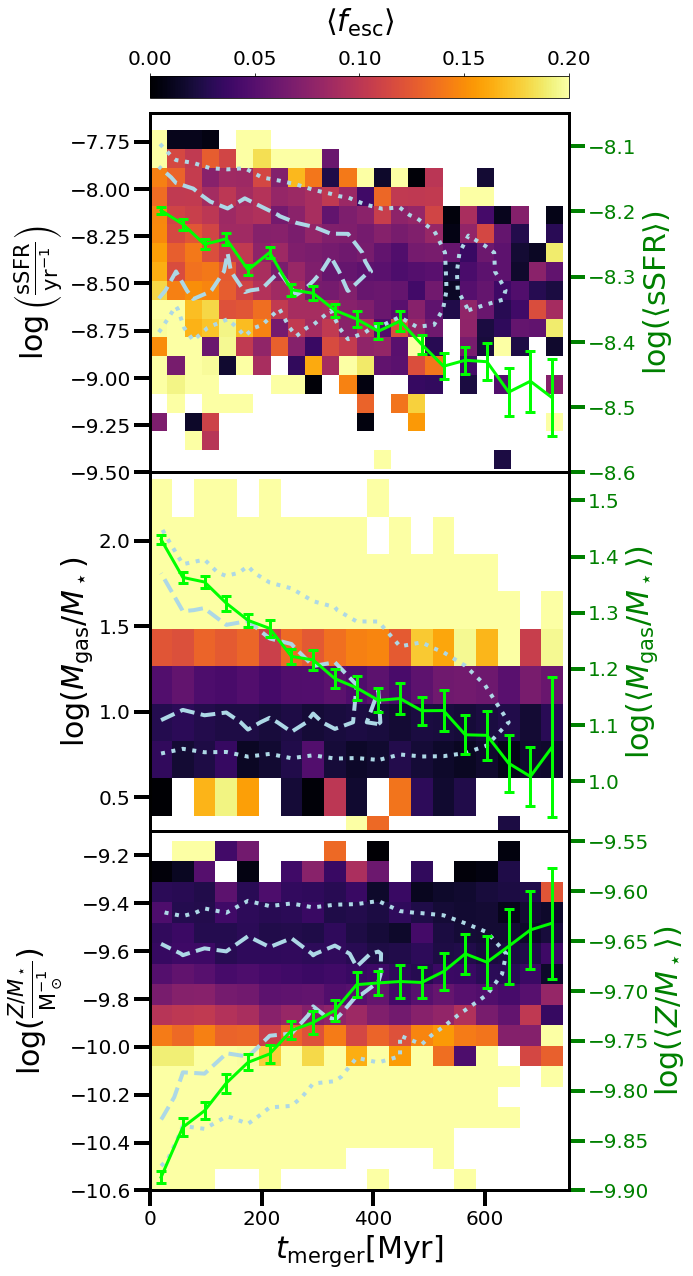

In [23]:
histograms_plot(
    df_full,
    add_line=True)

In [18]:
df_full['v_sigma'] = df_full['v_max']/df_full['abs_sigma_sfr']

In [87]:
df_full.keys(

Index(['r', 'Halo_pos_x', 'Halo_pos_y', 'Halo_pos_z', 'Grid_cell_size',
       'Column_height', 'Bol_em', 'Column_dens', 'Column_dens_stroemgren',
       'Dust_norm', 'Ion_em', 'M_gas', 'M_star', 'Metallicity', 'N_d',
       'N_ratio', 'N_red', 'SFR', 'U', 'U1', 'f_esc', 'f_g', 'f_g_crit',
       'n_gas', 'p_r', 'sigma_d_H', 'AverageColumnDens',
       'AverageColumnDensDust', 'AverageIonizableColumnDens', 'flow',
       'ang_momentum', 'sfr_mass_to_center_mass', 'sfr_sfr_to_center_mass',
       'abs_sigma_sfr', 'abs_sigma_mass', 'v_max', 'Dist_nearest', 'Dist_5',
       'Dist_10', 'Dist_32', 'TimeMajorMerger', 'TimeMinorMerger', 'Gini_sfr',
       'Gini_fesc', 'z', 'idx', 'M_gas_sun_log', 'M_star_sun_log', 'sSFR',
       'sZ', 'MgasMstar', 'L_M', 'Offset_pc'],
      dtype='object')

In [2]:
lineplots(
    df_full[(df_full.M_star_sun_log<9.0)],#&(np.log10(df_full.Column_height)>21)],
    mass_bins=10,
    em_weighted=False,
    x_prop="TimeMajorMerger",
    y_prop="f_esc",
    skip=4,
    params=None,
    log=False,
    individual_z=False,
    x_log=False,
    all=False,
    with_mass_bins=True,
    two_modes=False,
    filters=None,
)

NameError: name 'lineplots' is not defined

/freya/u/ivkos/semianalytic/plotting_routines.py:1651: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset="f_esc", inplace=True)
/u/ivkos/conda-envs/semianalytic/lib/python3.10/site-packages/numpy/core/_methods.py:44: RuntimeWarning: invalid value encountered in reduce
  return umr_minimum(a, axis, None, out, keepdims, initial, where)
/u/ivkos/conda-envs/semianalytic/lib/python3.10/site-packages/numpy/core/_methods.py:40: RuntimeWarning: invalid value encountered in reduce
  return umr_maximum(a, axis, None, out, keepdims, initial, where)
/u/ivkos/conda-envs/semianalytic/lib/python3.10/site-packages/numpy/core/_methods.py:44: RuntimeWarning: invalid value encountered in reduce
  return umr_minimum(a, axis, None, out, keepdims, initial, where)
/u/ivkos/conda-envs/semianalytic/lib/python3.10/

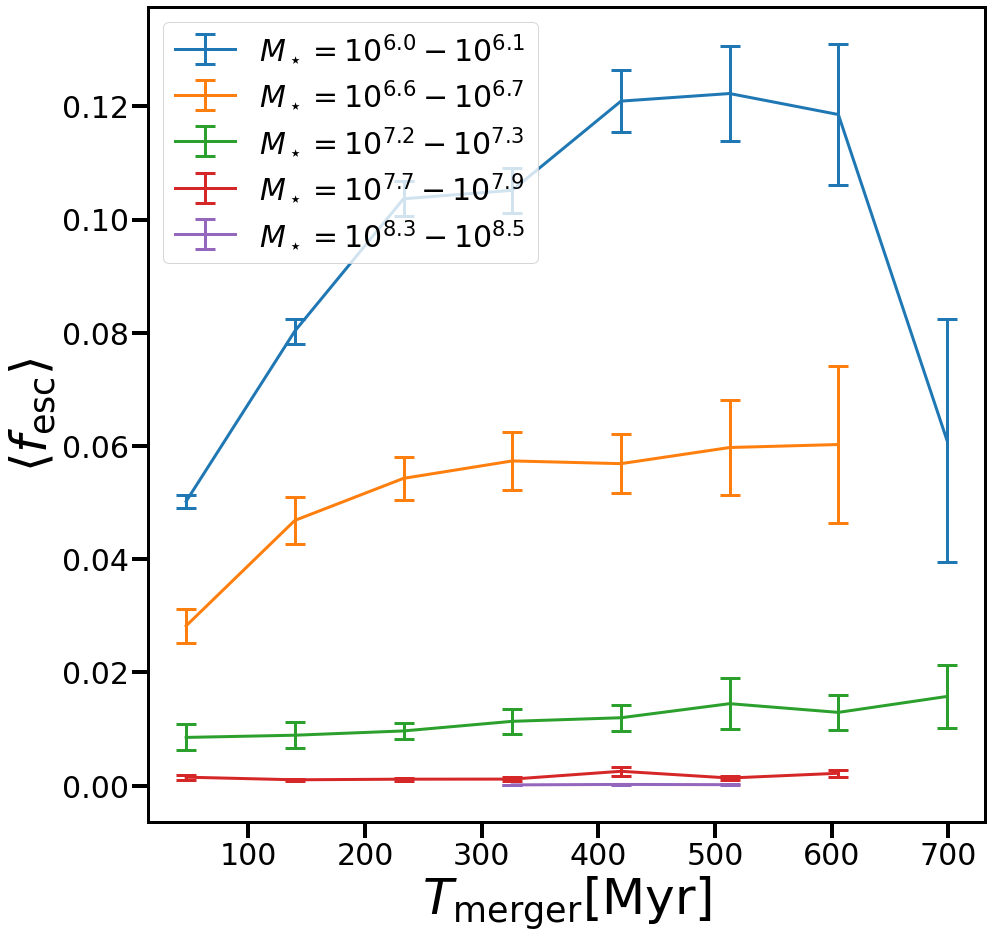

In [77]:
lineplots(
    df_full[(df_full.M_star_sun_log<8.9)&(np.log10(df_full.Column_height)<21)],
    mass_bins=10,
    em_weighted=False,
    x_prop="TimeMajorMerger",
    y_prop="f_esc",
    skip=4,
    params=None,
    log=False,
    individual_z=False,
    x_log=False,
    all=False,
    with_mass_bins=True,
    two_modes=False,
    filters=None,
)